# IMDB Sentiment Classification - Skills Assessment

Goal: train a model that predicts whether a movie review is **positive (1)** or **negative (0)**.

Dataset: IMDB movie reviews (Maas et al., 2011) - 25,000 training and 25,000 test reviews,
provided as `skills_assessment_data/train.json` and `skills_assessment_data/test.json`.

## 1. Load the dataset

In [1]:
import json
import pandas as pd

TRAIN_PATH = "skills_assessment_data/train.json"
TEST_PATH = "skills_assessment_data/test.json"

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_records = json.load(f)

with open(TEST_PATH, "r", encoding="utf-8") as f:
    test_records = json.load(f)

train_df = pd.DataFrame(train_records)
test_df = pd.DataFrame(test_records)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (25000, 2)
Test shape: (25000, 2)


In [2]:
# Display basic information about the dataset
print("-------------------- HEAD --------------------")
print(train_df.head())
print("-------------------- DESCRIBE --------------------")
print(train_df.describe(include="all"))
print("-------------------- INFO --------------------")
print(train_df.info())

-------------------- HEAD --------------------
                                                text  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1
-------------------- DESCRIBE --------------------
                                                     text        label
count                                               25000  25000.00000
unique                                              24904          NaN
top     You do realize that you've been watching the E...          NaN
freq                                                    3          NaN
mean                                                  NaN      0.50000
std                                                   NaN      0.50001
min                                          

In [3]:
# Check for missing values
print("Missing values (train):\n", train_df.isnull().sum())
print("Missing values (test):\n", test_df.isnull().sum())

Missing values (train):
 text     0
label    0
dtype: int64
Missing values (test):
 text     0
label    0
dtype: int64


In [4]:
# Check the label distribution - the IMDB dataset is balanced by design
print("Train label distribution:\n", train_df["label"].value_counts())
print("\nTest label distribution:\n", test_df["label"].value_counts())

Train label distribution:
 label
1    12500
0    12500
Name: count, dtype: int64

Test label distribution:
 label
1    12500
0    12500
Name: count, dtype: int64


In [5]:
# Check for duplicates and remove them from the training set only
print("Duplicate entries (train):", train_df.duplicated().sum())
train_df = train_df.drop_duplicates().reset_index(drop=True)
print("Train shape after removing duplicates:", train_df.shape)

Duplicate entries (train): 96
Train shape after removing duplicates: (24904, 2)


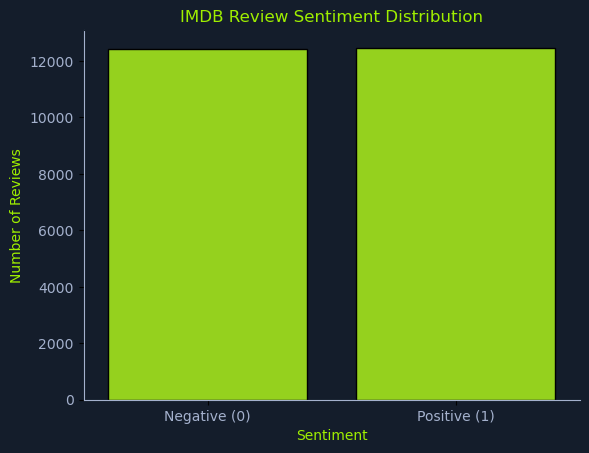

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# HTB Color Palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

# plot the class distribution of the training set
plt.figure(facecolor=node_black)
sns.barplot(
    x=["Negative (0)", "Positive (1)"],
    y=train_df["label"].value_counts().sort_index().values,
    edgecolor="black",
    color=htb_green,
)
plt.title("IMDB Review Sentiment Distribution", color=htb_green)
plt.xlabel("Sentiment", color=htb_green)
plt.ylabel("Number of Reviews", color=htb_green)
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines["bottom"].set_color(hacker_grey)
ax.spines["top"].set_color(node_black)
ax.spines["right"].set_color(node_black)
ax.spines["left"].set_color(hacker_grey)
plt.show()

## 2. Text preprocessing

The reviews are raw HTML-ish text, so we clean them step by step:
lowercasing, HTML tag removal, punctuation/number removal, tokenization,
stop word removal and stemming.

One important detail for **sentiment** analysis: negations (`not`, `never`, `no`, ...) are part of
NLTK's English stop word list, but they flip the polarity of a sentence
(*"not good"* vs. *"good"*). We therefore keep them.

In [7]:
import nltk

# Download the necessary NLTK data files
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("=== BEFORE ANY PREPROCESSING ===")
print(train_df["text"].head(2).tolist())

/home/kotaman/miniconda3/envs/ai/lib/python3.11/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/kotaman/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


=== BEFORE ANY PREPROCESSING ===
['Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High\'s satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers\' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I\'m here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn\'t!', 'Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once conside

[nltk_data] Downloading package punkt to /home/kotaman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/kotaman/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/kotaman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
import re

# The reviews contain HTML line breaks such as <br /> - remove all HTML tags
train_df["message"] = train_df["text"].apply(lambda x: re.sub(r"<[^>]+>", " ", x))
test_df["message"] = test_df["text"].apply(lambda x: re.sub(r"<[^>]+>", " ", x))
print("\n=== AFTER REMOVING HTML TAGS ===")
print(train_df["message"].head(2).tolist())


=== AFTER REMOVING HTML TAGS ===
['Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High\'s satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers\' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I\'m here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn\'t!', 'Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once consid

In [9]:
# Convert all review text to lowercase
train_df["message"] = train_df["message"].str.lower()
test_df["message"] = test_df["message"].str.lower()
print("\n=== AFTER LOWERCASING ===")
print(train_df["message"].head(3))


=== AFTER LOWERCASING ===
0    bromwell high is a cartoon comedy. it ran at t...
1    homelessness (or houselessness as george carli...
2    brilliant over-acting by lesley ann warren. be...
Name: message, dtype: str


In [10]:
# Remove non-essential punctuation and numbers, keep useful symbols like ! and ?
train_df["message"] = train_df["message"].apply(lambda x: re.sub(r"[^a-z\s!?]", " ", x))
test_df["message"] = test_df["message"].apply(lambda x: re.sub(r"[^a-z\s!?]", " ", x))
print("\n=== AFTER REMOVING PUNCTUATION & NUMBERS (except ! and ?) ===")
print(train_df["message"].head(3))


=== AFTER REMOVING PUNCTUATION & NUMBERS (except ! and ?) ===
0    bromwell high is a cartoon comedy  it ran at t...
1    homelessness  or houselessness as george carli...
2    brilliant over acting by lesley ann warren  be...
Name: message, dtype: str


In [11]:
from nltk.tokenize import word_tokenize

# Split each review into individual tokens
train_df["message"] = train_df["message"].apply(word_tokenize)
test_df["message"] = test_df["message"].apply(word_tokenize)
print("\n=== AFTER TOKENIZATION ===")
print(train_df["message"].head(3))


=== AFTER TOKENIZATION ===
0    [bromwell, high, is, a, cartoon, comedy, it, r...
1    [homelessness, or, houselessness, as, george, ...
2    [brilliant, over, acting, by, lesley, ann, war...
Name: message, dtype: object


In [12]:
from nltk.corpus import stopwords

# Negations carry the sentiment signal, so they are excluded from the stop word list
NEGATIONS = {
    "no", "nor", "not", "never", "none", "cannot", "don", "ain", "aren", "isn",
    "wasn", "weren", "didn", "doesn", "hasn", "haven", "hadn", "won", "wouldn",
    "shouldn", "couldn", "mustn", "mightn", "needn", "shan",
}

stop_words = set(stopwords.words("english")) - NEGATIONS

# Remove stop words and single characters left over from the cleaning step
def remove_stop_words(tokens):
    return [t for t in tokens if (t not in stop_words and len(t) > 1) or t in {"!", "?"}]

train_df["message"] = train_df["message"].apply(remove_stop_words)
test_df["message"] = test_df["message"].apply(remove_stop_words)
print("\n=== AFTER REMOVING STOP WORDS ===")
print(train_df["message"].head(3))


=== AFTER REMOVING STOP WORDS ===
0    [bromwell, high, cartoon, comedy, ran, time, p...
1    [homelessness, houselessness, george, carlin, ...
2    [brilliant, acting, lesley, ann, warren, best,...
Name: message, dtype: object


In [13]:
from nltk.stem import PorterStemmer

# Stem each token to reduce words to their base form
stemmer = PorterStemmer()
train_df["message"] = train_df["message"].apply(lambda x: [stemmer.stem(word) for word in x])
test_df["message"] = test_df["message"].apply(lambda x: [stemmer.stem(word) for word in x])
print("\n=== AFTER STEMMING ===")
print(train_df["message"].head(3))


=== AFTER STEMMING ===
0    [bromwel, high, cartoon, comedi, ran, time, pr...
1    [homeless, houseless, georg, carlin, state, is...
2    [brilliant, act, lesley, ann, warren, best, dr...
Name: message, dtype: object


In [14]:
# Rejoin tokens into a single string for feature extraction
train_df["message"] = train_df["message"].apply(lambda x: " ".join(x))
test_df["message"] = test_df["message"].apply(lambda x: " ".join(x))
print("\n=== AFTER JOINING TOKENS BACK INTO STRINGS ===")
print(train_df["message"].head(3))


=== AFTER JOINING TOKENS BACK INTO STRINGS ===
0    bromwel high cartoon comedi ran time program s...
1    homeless houseless georg carlin state issu yea...
2    brilliant act lesley ann warren best dramat ho...
Name: message, dtype: str


## 3. Feature extraction and model

Movie reviews are much longer than SMS messages, so raw counts favour long documents.
`TfidfVectorizer` with sublinear term frequency scaling weights rare, informative words higher.
Bigrams let the model learn phrases such as *"not good"* or *"waste time"*.

The classifier is a `LogisticRegression`, a strong and fast linear baseline for
high-dimensional sparse text features.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Unigrams + bigrams, ignore terms that are too rare or too common
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
)

# Build the pipeline by combining vectorization and classification
pipeline = Pipeline([
    ("vectorizer", vectorizer),
    ("classifier", LogisticRegression(max_iter=1000)),
])

# Features and labels
X_train, y_train = train_df["message"], train_df["label"]
X_test, y_test = test_df["message"], test_df["label"]

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning (C = inverse regularization strength)
param_grid = {
    "classifier__C": [1.0, 4.0, 10.0]
}

# Perform the grid search with 5-fold cross-validation and the F1-score as metric
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

# Fit the grid search on the training set only - the test set stays untouched
grid_search.fit(X_train, y_train)

# Extract the best model identified by the grid search
best_model = grid_search.best_estimator_
print("Best model parameters:", grid_search.best_params_)
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


## 4. Evaluation on the held-out test set

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Final evaluation on the test set
test_predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

print("Test Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
class_labels = ["Negative", "Positive"]
test_conf_matrix = confusion_matrix(y_test, test_predictions)
sns.heatmap(
    test_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.title("IMDB Sentiment Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(y_test, test_predictions, target_names=class_labels))

## 5. Inference on new reviews

In [ ]:
# Example movie reviews for evaluation
new_reviews = [
    "An absolute masterpiece. The acting was brilliant and the story kept me hooked from start to finish.",
    "One of the worst movies I have ever seen. The plot made no sense and the acting was terrible.",
    "I really wanted to like this film, but it was boring and far too long. Not worth the ticket price.",
    "A charming little movie with great performances and a soundtrack I am still humming days later.",
    "The special effects were nice, but that cannot save a predictable script and wooden dialogue.",
]

In [ ]:
# Preprocess function that mirrors the training-time preprocessing
def preprocess_review(review):
    review = re.sub(r"<[^>]+>", " ", review)
    review = review.lower()
    review = re.sub(r"[^a-z\s!?]", " ", review)
    tokens = word_tokenize(review)
    tokens = remove_stop_words(tokens)
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)


# Preprocess the new reviews
processed_reviews = [preprocess_review(review) for review in new_reviews]

In [ ]:
# Predict with the trained model
predictions = best_model.predict(processed_reviews)
prediction_probabilities = best_model.predict_proba(processed_reviews)

# Display predictions and probabilities for each evaluated review
for i, review in enumerate(new_reviews):
    prediction = "Positive (1)" if predictions[i] == 1 else "Negative (0)"
    positive_probability = prediction_probabilities[i][1]
    negative_probability = prediction_probabilities[i][0]

    print(f"Review: {review}")
    print(f"Prediction: {prediction}")
    print(f"Positive Probability: {positive_probability:.2f}")
    print(f"Negative Probability: {negative_probability:.2f}")
    print("-" * 50)

## 6. Save the trained model

In [ ]:
import joblib

# Save the trained model to a file for future use
model_filename = "sentiment_analysis_model.joblib"
joblib.dump(best_model, model_filename)

print(f"Model saved to {model_filename}")

In [ ]:
# Load the saved model and verify it produces the same predictions
loaded_model = joblib.load(model_filename)

new_data_processed = [preprocess_review(review) for review in new_reviews]
loaded_predictions = loaded_model.predict(new_data_processed)

print("Predictions from the loaded model:", loaded_predictions)
print("Identical to the in-memory model:", (loaded_predictions == predictions).all())